<a href="https://colab.research.google.com/github/tzelleke/jupyter-notebooks/blob/master/pandas/string-processing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

stateDiagram-v2
    direction TB
    [*] --> Aktiv: Neuanlage
    Aktiv --> [*]: loeschen
    Aktiv --> Archivierungspflichtig
    note left of Archivierungspflichtig
        Auftrag hat archivierte Termine.
    end note
    Archivierungspflichtig --> Archiviert: archivieren
    note right of Archiviert
        Auftrag nicht editierbar.
        Neue Termine koennen fuer den Auftrag
        nicht angelegt werden.
    end note
    Archiviert --> Archivierungspflichtig

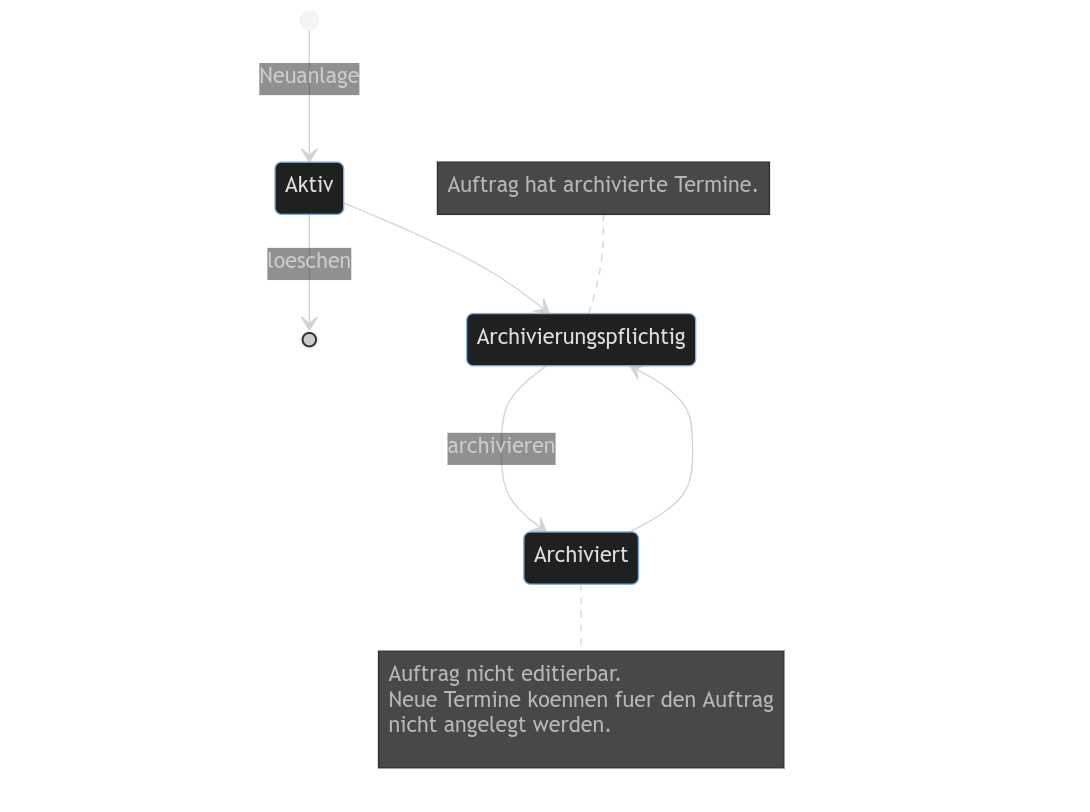

In [1]:
import io
import pandas as pd

## Two-step process: split-and-explode

Let us create some sample data.
In this dataset the `phones` column contains multiple phone numbers separated by comma for each record.

In [2]:
csv = io.StringIO('\n'.join([
    'id,name,phones',
    '1,Russel,"01234567,02345678,03456789"',
    '2,Patrick,"04123456,05234567,06345678"',
]))

df = pd.read_csv(csv, index_col='id')
df

,name,phones
id,,
1,Russel,"01234567,02345678,03456789"
2,Patrick,"04123456,05234567,06345678"


When reading this dataset to a dataframe using [pandas.read_csv](https://pandas.pydata.org/docs/reference/api/pandas.read_csv.html) we specify that the `id` column should populate the dataframe's index.

We are going to reshape the dataframe to hold a unique record for each phone number. This is a two-step process:

1.   Split the string in each cell of the `phones` column into a list of strings.
2.   Distrubute the list elements to individual rows.


In [3]:
df.assign(
    Phones=df.phones.str.split(',')
).explode('phones')

,name,phones,Phones
id,,,
1,Russel,"01234567,02345678,03456789","[01234567, 02345678, 03456789]"
2,Patrick,"04123456,05234567,06345678","[04123456, 05234567, 06345678]"


[DataFrame.assign](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.assign.html) adds new columns to a dataframe or overwrites existing ones.

Note, that after this operation the index `id` is no longer unique.

## Phone numbers with phone type

Next, we are going to look at a more complicated case where the `phones` column contains additional information on the type of a phone number.

In [4]:
csv = io.StringIO('\n'.join([
    'id,name,phones',
    '1,Russel,"mobil: 01234567\nwork: 02345678\nprivate: 03456789"',
    '2,Patrick,"mobil: 04123456\nprivate: 05234567"',
]))

df = pd.read_csv(csv, index_col='id')
df

,name,phones
id,,
1,Russel,mobil: 01234567\nwork: 02345678\nprivate: 0345...
2,Patrick,mobil: 04123456\nprivate: 05234567


dfdsfadsgfasdfa

In [5]:
(
    df.phones
    .str.split('\n').explode()
    .str.split(':', expand=True)
    .rename(columns={
        0: 'phone_type',
        1: 'phone_number',
    })
)

,phone_type,phone_number
id,,
1,mobil,01234567
1,work,02345678
1,private,03456789
2,mobil,04123456
2,private,05234567


We have transformed the `phones` series into a dataframe with columns `phone_type` and `phone_number`.

Let us join back this dataframe to the initial dataframe and drop the now redundant `phones` column.

In [6]:
df.join(
    df.phones
        .str.split('\n').explode()
        .str.split(':', expand=True)
        .rename(columns={
            0: 'phone_type',
            1: 'phone_number',
        })
).drop('phones', axis='columns')

,name,phone_type,phone_number
id,,,
1,Russel,mobil,01234567
1,Russel,work,02345678
1,Russel,private,03456789
2,Patrick,mobil,04123456
2,Patrick,private,05234567


### Reshaping to wide format

We can reshape this dataframe to a wide format by using the idiom  
`DataFrame.set_index('<COLUMN>', append=True).unstack('<COLUMN>')`.  
[set_index](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.set_index.html) sets the DataFrame index using existing columns.
If we specify `append=True` the column is added to the existing index instead of replacing it.
Thus, after this operation the dataframe contains a MultiIndex.

In [7]:
(
    df.phones
    .str.split('\n').explode()
    .str.split(':', expand=True)
    .rename(columns={
        0: 'phone_type',
        1: 'phone_number',
    })
    .set_index('phone_type', append=True)
    .unstack('phone_type').droplevel(0, axis='columns')
)

phone_type,mobil,private,work
id,,,
1,01234567,03456789,02345678
2,04123456,05234567,NaN


Again, we need to join back the reshaped dataframe to the initial dataframe and drop the initial `phones` column.

In [8]:
df.join(
    df.phones
    .str.split('\n').explode()
    .str.split(':', expand=True)
    .rename(columns={
        0: 'phone_type',
        1: 'phone_number',
    })
    .set_index(['phone_type'], append=True)
    .unstack('phone_type').droplevel(0, axis='columns')
).drop('phones', axis='columns')

,name,mobil,private,work
id,,,,
1,Russel,01234567,03456789,02345678
2,Patrick,04123456,05234567,NaN
